### Supplementary Information

**Title:** Project Notebook for Machine Learning to Predict Digital Frustration from Clickstream Data

**Author:** Jibin Joseph

**Description:**
This supplementary file provides the project notebook used for the study. It includes the main steps for loading the Coveo clickstream dataset, sessionizing user events, creating rule-based frustration labels, extracting features, training machine learning models, and evaluating model performance. This file is provided to support reproducibility of the results reported in the manuscript.

### Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_data = pd.read_csv('/content/drive/MyDrive/1_MSAI/6_CSML/Final_Project/data/release_10_23_2020.csv')

#### Basic checks

In [ ]:
df_data.shape

(5433611, 6)

In [ ]:
df_data.head()

,session_id_hash,event_type,product_action,product_skus_hash,server_timestamp_epoch_ms,hashed_url
0,00000005c19449b57d8d05dfc8b5474be0654032,pageview,NaN,NaN,1544469996111,da99729886aff70a02733b6cd69ee7df35622d9302347e...
1,00006a0ada94a5186163a25e9ed9c94481c820d9,pageview,NaN,NaN,1545737959865,e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9abf...
2,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908835402,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...
3,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908847263,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...
4,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,detail,90add4dd072e160034e98ddea257e0b59441eae00d8955...,1544909035879,8fa1ecf31ececb27ebe9c529966f3d1f907542fe138d5d...


In [ ]:
df_data.dtypes

,0
session_id_hash,object
event_type,object
product_action,object
product_skus_hash,object
server_timestamp_epoch_ms,int64
hashed_url,object


In [ ]:
df_data['event_type'].unique()

array(['pageview', 'event'], dtype=object)

In [ ]:
df_data['product_action'].unique()

array([nan, 'detail', 'click', 'add', 'purchase', 'remove'], dtype=object)

In [ ]:
df_data.groupby(by='event_type')['product_action'].value_counts(dropna=False)

event_type  product_action
event       add                743363
            click               69831
            remove              51512
            NaN                  3652
pageview    NaN               2915137
            detail            1640190
            purchase             9926
Name: count, dtype: int64

### Sessionize

#### 1. Symbolize

dataset into symbolic trajectories with minimal information
predictability of user intent based purely on the sequence of their actions
Demonstrating that prediction is possible even with minimal information
1 = page view (any page load with no specific product action),
2 = product detail view,
3 = add to cart,
4 = remove from cart,
5 = purchase,
6 = click on a search result.

In [ ]:
# product_action is one of {detail, add, remove, purchase, click} or empty (for simple page views).
mapping = {'detail': 2, 'click': 3, 'add': 4, 'remove': 5, 'purchase': 6}

In [ ]:
df_data['symbol'] = df_data['product_action'].map(mapping)

In [ ]:
df_data.head()

,session_id_hash,event_type,product_action,product_skus_hash,server_timestamp_epoch_ms,hashed_url,symbol
0,00000005c19449b57d8d05dfc8b5474be0654032,pageview,NaN,NaN,1544469996111,da99729886aff70a02733b6cd69ee7df35622d9302347e...,NaN
1,00006a0ada94a5186163a25e9ed9c94481c820d9,pageview,NaN,NaN,1545737959865,e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9abf...,NaN
2,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908835402,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...,NaN
3,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908847263,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...,NaN
4,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,detail,90add4dd072e160034e98ddea257e0b59441eae00d8955...,1544909035879,8fa1ecf31ececb27ebe9c529966f3d1f907542fe138d5d...,2.0


In [ ]:
df_data['symbol'] = df_data['symbol'].fillna(1)

In [ ]:
df_data['symbol'] = df_data['symbol'].astype(int)

In [ ]:
df_data.head()

,session_id_hash,event_type,product_action,product_skus_hash,server_timestamp_epoch_ms,hashed_url,symbol
0,00000005c19449b57d8d05dfc8b5474be0654032,pageview,NaN,NaN,1544469996111,da99729886aff70a02733b6cd69ee7df35622d9302347e...,1
1,00006a0ada94a5186163a25e9ed9c94481c820d9,pageview,NaN,NaN,1545737959865,e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9abf...,1
2,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908835402,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...,1
3,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,NaN,NaN,1544908847263,ea7b2493be61ff454f8cce412f9dc281e605daec8c43b5...,1
4,00007d15aeb741b3cdd873cb3933351d699cc320,pageview,detail,90add4dd072e160034e98ddea257e0b59441eae00d8955...,1544909035879,8fa1ecf31ececb27ebe9c529966f3d1f907542fe138d5d...,2


In [ ]:
# min, max server_timestamp_epoch_ms and convert to date
print(df_data['server_timestamp_epoch_ms'].min())

1544227200486


In [ ]:
converted_timestamps = pd.to_datetime(df_data['server_timestamp_epoch_ms'], unit='ms')
print(f"Minimum timestamp: {converted_timestamps.min()}")
print(f"Maximum timestamp: {converted_timestamps.max()}")

Minimum timestamp: 2018-12-08 00:00:00.486000
Maximum timestamp: 2018-12-25 23:59:57.577000


#### 2. Sessionize

In [ ]:
# Ensure events are in chronological order within each session
df_session = df_data.sort_values(by=['session_id_hash',
                                     'server_timestamp_epoch_ms'])

In [ ]:
#df_session.sort_values?

In [ ]:

df_session = df_session.groupby(by='session_id_hash')[['symbol', 'hashed_url',
                                          'server_timestamp_epoch_ms']].agg(list)

In [ ]:
df_session.shape

(443660, 3)

In [ ]:
df_session.head()

,symbol,hashed_url,server_timestamp_epoch_ms
session_id_hash,,,
00000005c19449b57d8d05dfc8b5474be0654032,[1],[da99729886aff70a02733b6cd69ee7df35622d9302347...,[1544469996111]
00006a0ada94a5186163a25e9ed9c94481c820d9,[1],[e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9ab...,[1545737959865]
00007d15aeb741b3cdd873cb3933351d699cc320,"[1, 1, 2, 1, 2, 1, 2]",[ea7b2493be61ff454f8cce412f9dc281e605daec8c43b...,"[1544908835402, 1544908847263, 1544909035879, ..."
0000c49d1359c87f112285d63a9fc0d4c50f73b4,"[1, 1, 1]",[2521db8294288fdde2c3ea93cfdab023c8cfd77e5eee1...,"[1544780629084, 1544780652666, 1544780882467]"
0001135282dbaf0e734345212ea6f8da9f5b66ed,[1],[2a0742673634bd031e0e81714906115944e5b980d8faf...,[1544422592886]


### EDA

### Labeling
- identify high impact frustration events
- Label the sessionized data as 1 (frustrated) or 0 (not frustrated)

#### identify high impact frustration events

#### 1. Rage clicks (classic frustration signal)


Product analytics tools define rage clicks as 3+ clicks on the same element in a very short window (e.g. ≤2 seconds).
https://amplitude.com/explore/analytics/rage-clicks

Approximation with what you have:

Same hashed_url

Consecutive events

Time deltas < 2s

Burst length ≥ 3

That gives you a per-session rage_bursts count.

### 2. U-turns / backtracking

Tools like Hotjar, Contentsquare, and others use U-turns as frustration: going to a page and very quickly coming straight back.

https://capturly.com/blog/what-are-rage-clicks-and-how-to-improve-your-websites-usability-with-them/

https://www.twipla.com/en/blog/alarming-behavior-tracking-dead-clicks-rage-clicks-and-more

https://cxl.com/blog/user-frustration


You can approximate:

Sequence pattern A → B → A in hashed_url

Or: navigate from page A to B but return to A within a few seconds and with no cart or purchase actions in between.

Count those as u_turns.

### 3 Cart churn: add → remove with no purchase

Sessions where the user adds to cart (4) and then removes (5) but never purchases (6) are strong candidates for frustration (price shock, error, stock, etc.).

Signals:

has_add = 4 in symbols

has_remove = 5 in symbols

has_purchase = 6 in symbols

cart_churn = has_add and has_remove and not has_purchase

You can also count add_remove_cycles (multiple add/remove pairs).

### 4 Search struggle: many result clicks, no progress

From product analytics and search-log research, lots of query/result interactions with no success is a struggle / frustration indicator.

https://joinground.com/seo-blogs/ecommerce-personalization-tools

https://deepai.org/publication/feature-modulation-to-improve-struggle-detection-in-web-search-a-psychological-approach

Your proxy (because you’ve symbolized like Requena et al., just with different indices
PMC
):

search_clicks = count(symbol == 3)

No add (4) and no purchase (6)

Possibly short dwell times between those clicks.

Example rule:

search_frustration = search_clicks >= 3 and not has_add and not has_purchase

You can refine with dwell time (e.g. many 3→1 or 3→3 jumps with < N seconds on page).

### 5 Long wandering with no success

Some sessions just wander:

Long duration (e.g. > 5–10 minutes)

Many events (length of symbols high)

Many product details (2) but no add/purchase.

These can be “research” or “frustration”; but high effort + no progress is often treated as struggle in search literature.

https://deepai.org/publication/feature-modulation-to-improve-struggle-detection-in-web-search-a-psychological-approach

https://joinground.com/seo-blogs/ecommerce-personalization-tools



#### Labeling

**Important:** Make sure to run the code cells for functions count_rage_bursts, and count_u_turns before running the function label_session

In [ ]:
def label_session(row):
    symbols = row['symbol']
    urls    = row['hashed_url']
    times   = row['server_timestamp_epoch_ms']
    n = len(symbols)
    if n == 0:
        return pd.Series({
            'frustration_label': 0,
            'rage_bursts': 0,
            'u_turns': 0,
            'cart_churn': 0,
            'search_frustration': 0,
            'long_wander': 0,
        })

    has_purchase = 6 in symbols
    has_add      = 4 in symbols
    has_remove   = 5 in symbols

    rage_bursts = count_rage_bursts(urls, times, max_gap_ms=2000, min_repeat=3)

    u_turns = count_u_turns(symbols, urls, times, max_gap_ms=2000)

    cart_churn = int(has_add and has_remove and not has_purchase)

    search_clicks = sum(1 for s in symbols if s == 3)
    search_frustration = int(search_clicks >= 3 and not has_add and not has_purchase)

    duration_sec = (times[-1] - times[0]) / 1000.0
    detail_views = sum(1 for s in symbols if s == 2)
    long_wander = int(duration_sec > 1200 and detail_views >= 5 and not has_purchase)

    flag = int(
        (rage_bursts > 0) or
        (u_turns > 0) or
        cart_churn or
        search_frustration or
        long_wander
    )

    return pd.Series({
        'frustration_label': flag,
        'rage_bursts': rage_bursts,
        'u_turns': u_turns,
        'cart_churn': cart_churn,
        'search_frustration': search_frustration,
        'long_wander': long_wander,
    })

# apply once and get all columns
df_session[['frustration_label',
            'rage_bursts',
            'u_turns',
            'cart_churn',
            'search_frustration',
            'long_wander']] = df_session.apply(label_session, axis=1)


In [ ]:
totals = df_session[['frustration_label','rage_bursts',
                     'u_turns',
                     'cart_churn',
                     'search_frustration',
                     'long_wander']].sum()

print(totals)

frustration_label     57736
rage_bursts           15442
u_turns                1753
cart_churn             8434
search_frustration     4829
long_wander           47710
dtype: int64


In [ ]:
def count_rage_bursts(urls, times, max_gap_ms=2000, min_repeat=3):
    bursts = 0
    run_len = 1
    n = len(urls)
    for i in range(1, n):
        same_target = urls[i] == urls[i-1]
        close_in_time = (times[i] - times[i-1]) <= max_gap_ms
        if same_target and close_in_time:
            run_len += 1
        else:
            if run_len >= min_repeat:
                bursts += 1
            run_len = 1
    if run_len >= min_repeat:
        bursts += 1
    return bursts

In [ ]:
UTURN_MS = 2000  # 2 seconds

def count_u_turns(symbols, urls, times, max_gap_ms=UTURN_MS):
    """
    Count U-turns in a session.

    U-turn = A -> B -> A (on the page level)
    where:
      - A, B, A are consecutive distinct pages (not just events)
      - time(A2) - time(B) <= max_gap_ms
      - no cart (4) or purchase (6) events between B and A2
    """

    n = len(urls)
    if n < 3:
        return 0

    # 1) Compress consecutive events on the same URL into page-level visits
    page_urls = []
    page_times = []

    last_url = None
    for u, t in zip(urls, times):
        if u != last_url:
            page_urls.append(u)
            page_times.append(t)
            last_url = u

    m = len(page_urls)
    if m < 3:
        return 0

    u_turns = 0

    # 2) Look for A -> B -> A patterns at the page level
    for i in range(m - 2):
        A1, t_A1 = page_urls[i], page_times[i]
        B,  t_B  = page_urls[i+1], page_times[i+1]
        A2, t_A2 = page_urls[i+2], page_times[i+2]

        # A -> B -> A with B different
        if A1 == A2 and A1 != B:
            # must return within max_gap_ms
            if (t_A2 - t_B) <= max_gap_ms:
                # 3) Check there is NO cart or purchase between B and A2
                has_cart_or_purchase = any(
                    (t_B <= t <= t_A2) and (s in (4, 6))
                    for s, t in zip(symbols, times)
                )
                if not has_cart_or_purchase:
                    u_turns += 1

    return u_turns


In [ ]:
df_session['frustration_label'].value_counts()

,count
frustration_label,
0,385924
1,57736


In [ ]:
df_session['frustration_label'].value_counts(normalize =  True)

,proportion
frustration_label,
0,0.869864
1,0.130136


In [ ]:
df_session.shape

(443660, 9)

In [ ]:
df_session[(df_session['symbol'].apply(len) >= 2) &
 (df_session['symbol'].apply(len) <= 1000)].shape

(304893, 9)

In [ ]:
304893/443660

0.6872221971780192

In [ ]:
df_session[(df_session['symbol'].apply(len) >= 2) &
 (df_session['symbol'].apply(len) <= 1000)]['frustration_label'].value_counts()

,count
frustration_label,
0,247267
1,57626


In [ ]:
df_session[(df_session['symbol'].apply(len) > 1000)]['frustration_label'].value_counts()

,count
frustration_label,
1,110
0,1


#### Single clicks

In [ ]:
df_session[(df_session['symbol'].apply(len) < 2)]['frustration_label'].value_counts()

,count
frustration_label,
0,138656


In [ ]:
df_session[(df_session['symbol'].apply(len) < 2)]['frustration_label'].shape

(138656,)

### Remove class information from sequences

In [ ]:
df_session.head()

,symbol,hashed_url,server_timestamp_epoch_ms,frustration_label,rage_bursts,u_turns,cart_churn,search_frustration,long_wander
session_id_hash,,,,,,,,,
00000005c19449b57d8d05dfc8b5474be0654032,[1],[da99729886aff70a02733b6cd69ee7df35622d9302347...,[1544469996111],0,0,0,0,0,0
00006a0ada94a5186163a25e9ed9c94481c820d9,[1],[e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9ab...,[1545737959865],0,0,0,0,0,0
00007d15aeb741b3cdd873cb3933351d699cc320,"[1, 1, 2, 1, 2, 1, 2]",[ea7b2493be61ff454f8cce412f9dc281e605daec8c43b...,"[1544908835402, 1544908847263, 1544909035879, ...",0,0,0,0,0,0
0000c49d1359c87f112285d63a9fc0d4c50f73b4,"[1, 1, 1]",[2521db8294288fdde2c3ea93cfdab023c8cfd77e5eee1...,"[1544780629084, 1544780652666, 1544780882467]",0,0,0,0,0,0
0001135282dbaf0e734345212ea6f8da9f5b66ed,[1],[2a0742673634bd031e0e81714906115944e5b980d8faf...,[1544422592886],0,0,0,0,0,0


In [ ]:
for a, b in df_session[['symbol']].head().items():
  print(a)
  print(b)

symbol
session_id_hash
00000005c19449b57d8d05dfc8b5474be0654032                      [1]
00006a0ada94a5186163a25e9ed9c94481c820d9                      [1]
00007d15aeb741b3cdd873cb3933351d699cc320    [1, 1, 2, 1, 2, 1, 2]
0000c49d1359c87f112285d63a9fc0d4c50f73b4                [1, 1, 1]
0001135282dbaf0e734345212ea6f8da9f5b66ed                      [1]
Name: symbol, dtype: object


In [ ]:
df_session["symbol"].str.len().max()

7579

In [ ]:
df_session.head()

,symbol,hashed_url,server_timestamp_epoch_ms,frustration_label,rage_bursts,u_turns,cart_churn,search_frustration,long_wander
session_id_hash,,,,,,,,,
00000005c19449b57d8d05dfc8b5474be0654032,[1],[da99729886aff70a02733b6cd69ee7df35622d9302347...,[1544469996111],0,0,0,0,0,0
00006a0ada94a5186163a25e9ed9c94481c820d9,[1],[e2f7e0cee4272e804f0d323a3513dd01716a5a40ab9ab...,[1545737959865],0,0,0,0,0,0
00007d15aeb741b3cdd873cb3933351d699cc320,"[1, 1, 2, 1, 2, 1, 2]",[ea7b2493be61ff454f8cce412f9dc281e605daec8c43b...,"[1544908835402, 1544908847263, 1544909035879, ...",0,0,0,0,0,0
0000c49d1359c87f112285d63a9fc0d4c50f73b4,"[1, 1, 1]",[2521db8294288fdde2c3ea93cfdab023c8cfd77e5eee1...,"[1544780629084, 1544780652666, 1544780882467]",0,0,0,0,0,0
0001135282dbaf0e734345212ea6f8da9f5b66ed,[1],[2a0742673634bd031e0e81714906115944e5b980d8faf...,[1544422592886],0,0,0,0,0,0


In [ ]:
sequences = []  # list of symbol sequences for each session
labels = []     # corresponding labels (1 for frustration, 0 for non-frustration)
timestamps  = []  # list of timestamp sequences aligned with sequences
for session_id, row in df_session.iterrows():
    seq = row['symbol']
    times = list(row['server_timestamp_epoch_ms'])
    label = row['frustration_label']

    # Trim sequence at the first purchase (do not include the purchase event)
    # Check if 'purchase' (symbol 6) exists before trimming
    # The original code was using symbol 5 for remove, but based on the problem description:
    # 6 = purchase, 5 = remove from cart
    # Assuming the intention was to trim before a 'purchase' (symbol 6)
    if 6 in seq:
        first_purchase_idx = seq.index(6)
        seq = seq[:first_purchase_idx]
        times = times[:first_purchase_idx]

    # Filter out sequences too short or too long as required for feature extraction
    if len(seq) >= 2 and len(seq) <= 1000:
        assert len(seq) == len(times), "Sequence and timestamp length mismatch"
        sequences.append(seq)
        timestamps.append(times)
        labels.append(label)

print(f"Total sessions after preprocessing: {len(sequences)}")
print(f"Frustration: {sum(labels)} ({100*sum(labels)/len(labels):.2f}%); Non-Frustration: {len(labels)-sum(labels)}")

Total sessions after preprocessing: 304881
Frustration: 57642 (18.91%); Non-Frustration: 247239


### Classical ML

#### Feature Engineering

In [ ]:
from math import log, pi, sin, cos
import datetime as dt
from collections import Counter

# Define the set of possible symbols in sequences (excluding 5 which is removed)
symbol_set = [1, 2, 3, 4, 6]

def extract_features(seq, times):
    L = len(seq)
    # 1-gram frequencies P(s) for s in {1,2,3,4,6}
    count1 = Counter(seq)
    # Ensure no '5' (purchase) in seq; count1[5] would be 0 anyway since we trimmed all 5's.
    features = [count1.get(sym, 0) / L for sym in symbol_set]

    # 2-gram frequencies P(s_i, s_{i+1}) for all ordered pairs of symbols in {1,2,3,4,6}
    count2 = Counter()
    for i in range(L - 1):
        a, b = seq[i], seq[i+1]
        if a == 5 or b == 5:
            # (In theory this never happens, but just in case, skip any pair involving 5)
            continue
        count2[(a, b)] += 1
    total_pairs = L - 1 if L > 1 else 1  # avoid division by zero (L>=5 here, so L-1 >=4)
    for a in symbol_set:
        for b in symbol_set:
            features.append(count2.get((a, b), 0) / total_pairs)

    # HVG motif counts (order-4 motifs)
    motif_counts = [0] * 6  # there are 6 possible motifs of order 4
    if L >= 4:
        # Slide a window of 4 symbols along the sequence
        for i in range(L - 3):
            x1, x2, x3, x4 = seq[i], seq[i+1], seq[i+2], seq[i+3]
            # Determine visibility edges among these 4 points:
            a_vis = x2 < min(x1, x3)            # edge between positions 1 and 3
            b_vis = x3 < min(x2, x4)            # edge between positions 2 and 4
            c_vis = (x2 < min(x1, x4)) and (x3 < min(x1, x4))  # edge between 1 and 4
            # Encode the presence of these additional edges as a 3-bit number:
            code = (int(a_vis) << 2) | (int(b_vis) << 1) | int(c_vis)
            # Map the code to a motif index 0-5 (skip invalid codes 6 or 7 which shouldn't occur&#8203;:contentReference[oaicite:20]{index=20})
            if code == 0:    # 000: no additional edges
                motif_idx = 0  # Motif 1
            elif code == 4:  # 100: only edge 1-3
                motif_idx = 1  # Motif 2
            elif code == 2:  # 010: only edge 2-4
                motif_idx = 2  # Motif 3
            elif code == 1:  # 001: only edge 1-4
                motif_idx = 3  # Motif 4
            elif code == 5:  # 101: edges 1-3 and 1-4
                motif_idx = 4  # Motif 5
            elif code == 3:  # 011: edges 2-4 and 1-4
                motif_idx = 5  # Motif 6
            else:
                continue  # code 6 or 7 (shouldn't happen for a valid visibility graph)
            motif_counts[motif_idx] += 1
    # Convert motif counts to probabilities Z_i
    total_motifs = sum(motif_counts)
    if total_motifs > 0:
        Z = [count / total_motifs for count in motif_counts]
    else:
        Z = [0]*6
    features.extend(Z)
    # Compute entropy of motif profile h_z
    h_z = 0.0
    for p in Z:
        if p > 0:
            h_z -= p * log(p)
    features.append(h_z)


    # ---------- NEW FEATURES BEGIN HERE ----------

    # 1) sequence length
    seq_len = L

    # 2) depth: number of unique symbols/pages
    # If you prefer pages, pass URLs and use len(set(urls)) instead.
    depth = len(set(seq))

    # 3) session duration (seconds)
    if L > 1:
        duration_sec = max((times[-1] - times[0]) / 1000.0, 0.0)
    else:
        duration_sec = 0.0

    # 4) click density = sequence length / duration
    if duration_sec > 0:
        click_density = seq_len / duration_sec
    else:
        click_density = 0.0

    # 5) sequence length / depth
    if depth > 0:
        len_over_depth = seq_len / depth
    else:
        len_over_depth = 0.0

    # 6–11) temporal cyclic features (use first timestamp)
    t0 = times[0] / 1000.0
    dt0 = dt.datetime.utcfromtimestamp(t0)  # or .fromtimestamp depending on your TZ convention

    hour  = dt0.hour          # 0–23
    dow   = dt0.weekday()     # 0=Mon..6=Sun
    month = dt0.month         # 1–12

    hour_sin  = sin(2 * pi * hour / 24.0)
    hour_cos  = cos(2 * pi * hour / 24.0)
    dow_sin   = sin(2 * pi * dow / 7.0)
    dow_cos   = cos(2 * pi * dow / 7.0)
    month_sin = sin(2 * pi * (month - 1) / 12.0)  # months as 0–11
    month_cos = cos(2 * pi * (month - 1) / 12.0)

    features.extend([
        # seq_len,
        # depth,
        # duration_sec,
        # click_density,
        # len_over_depth,
        hour_sin, hour_cos,
        dow_sin,  dow_cos,
        # month_sin, month_cos,
    ])

    # ---------- NEW FEATURES END HERE ----------

    return features

# Extract features for all sessions
feature_list = feature_list = [
    extract_features(seq, times)
    for seq, times in zip(sequences, timestamps)
]

# Define feature names for clarity (5 one-grams, 25 two-grams, 6 motifs, 1 entropy = 37 features)
onegram_names = [f"P({s})" for s in symbol_set]
bigram_names  = [f"P({a},{b})" for a in symbol_set for b in symbol_set]
motif_names   = [f"Z{i}" for i in range(1, 7)] + ["h_z"]

extra_names = [
    # "seq_len",
    # "depth",
    # "duration_sec",
    # "click_density",
    # "len_over_depth",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    # "month_sin",
    # "month_cos",
]

feature_names = onegram_names + bigram_names + motif_names + extra_names

X_features = pd.DataFrame(feature_list, columns=feature_names)
y = pd.Series(labels, name="label")

/tmp/ipython-input-996961352.py:100: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt0 = dt.datetime.utcfromtimestamp(t0)  # or .fromtimestamp depending on your TZ convention


In [ ]:
X_features.head()

,P(1),P(2),P(3),P(4),P(6),"P(1,1)","P(1,2)","P(1,3)","P(1,4)","P(1,6)",...,Z2,Z3,Z4,Z5,Z6,h_z,hour_sin,hour_cos,dow_sin,dow_cos
0,0.571429,0.428571,0.0000,0.0,0.0,0.166667,0.500000,0.0,0.0,0.0,...,0.250000,0.500000,0.0,0.0,0.0,1.039721,-0.707107,0.707107,-0.974928,-0.222521
1,1.000000,0.000000,0.0000,0.0,0.0,1.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.707107,-0.707107,-0.433884,-0.900969
2,0.812500,0.125000,0.0625,0.0,0.0,0.666667,0.133333,0.0,0.0,0.0,...,0.076923,0.076923,0.0,0.0,0.0,0.535961,0.965926,-0.258819,-0.781831,0.623490
3,1.000000,0.000000,0.0000,0.0,0.0,1.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.965926,-0.258819,-0.974928,-0.222521
4,0.600000,0.200000,0.2000,0.0,0.0,0.250000,0.250000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.866025,-0.500000,0.000000,1.000000


### Additional features

- sequence length
- depth (number ofunique pages in the sequence)
- session duration
- click density: sequence length / session duration
- sequence length / depth
- hour of day sin, cos
- day of week sin, cos
- month of year sin, cos

In [ ]:
import pandas as pd

# 1. Compute skewness for each feature
skew_vals = X_features.skew(numeric_only=True)

# 2. Sort by skew (just to inspect)
skew_sorted = skew_vals.sort_values(ascending=False)
print("Skew (descending):")
print(skew_sorted)

# 3. Identify highly skewed features (e.g. |skew| > 1)
threshold = 1.0
high_skew = skew_vals[skew_vals.abs() > threshold].sort_values(key=lambda s: s.abs(), ascending=False)

print("\nHighly skewed features (|skew| > 1):")
print(high_skew)


Skew (descending):
P(4,3)      222.396189
P(3,3)      122.921489
Z6           22.870664
P(1,4)       20.594862
P(4,2)       19.584384
P(3,4)       19.438448
P(3,2)       12.744423
P(2,4)       10.282792
P(4,4)       10.227252
Z5            9.876961
P(1,3)        9.826246
P(2,3)        8.865400
Z4            7.833977
P(3,1)        7.570944
P(4)          7.351699
P(4,1)        6.636828
P(3)          5.014885
P(2,2)        3.043956
Z2            1.487223
Z3            1.452517
P(2,1)        1.045008
P(1,2)        1.013868
P(2)          0.921730
hour_cos      0.564534
P(1,1)        0.412585
h_z           0.410935
hour_sin      0.147290
Z1            0.004672
P(6)          0.000000
P(4,6)        0.000000
P(3,6)        0.000000
P(1,6)        0.000000
P(2,6)        0.000000
P(6,1)        0.000000
P(6,6)        0.000000
P(6,3)        0.000000
P(6,4)        0.000000
P(6,2)        0.000000
dow_sin      -0.077540
dow_cos      -0.250619
P(1)         -0.648319
dtype: float64

Highly skewed features

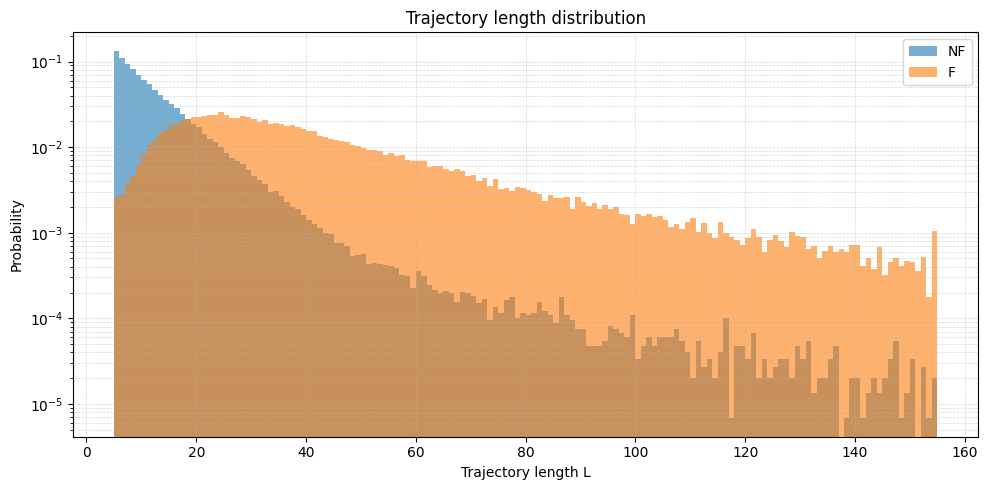

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate lengths of each sequence
lengths = [len(seq) for seq in sequences]
labels_np = np.array(labels)  # Convert to NumPy array for indexing

# Separate lengths by class
nc_lengths = [lengths[i] for i in range(len(lengths)) if labels[i] == 0]
c_lengths  = [lengths[i] for i in range(len(lengths)) if labels[i] == 1]

# Plotting
plt.figure(figsize=(10, 5))
bins = np.arange(5, 156)  # As specified: 5 ≤ L ≤ 155

plt.hist(nc_lengths, bins=bins, density=True, alpha=0.6, color='tab:blue', label='NF')
plt.hist(c_lengths, bins=bins, density=True, alpha=0.6, color='tab:orange', label='F')

plt.yscale('log')
plt.xlabel('Trajectory length L')
plt.ylabel('Probability')
plt.title('Trajectory length distribution')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('trejectory_lengths.png') # Save the plot as a PNG file
plt.show()


### Test train split

In [ ]:
from sklearn.model_selection import train_test_split

# Convert features and labels to numpy for modeling
X = X_features.values
y_arr = y.values

# Separate conversion and non-conversion indices for stratified sampling
conv_indices = [i for i, lbl in enumerate(y_arr) if lbl == 1]
nc_indices = [i for i, lbl in enumerate(y_arr) if lbl == 0]

# Shuffle the indices
import numpy as np
np.random.shuffle(conv_indices)
np.random.shuffle(nc_indices)

# Determine split sizes
num_conv = len(conv_indices)
train_size = int(0.70 * num_conv)
val_size = int(0.15 * num_conv)
test_size = num_conv - train_size - val_size

# Select conversion subsets
train_conv_idx = conv_indices[:train_size]
val_conv_idx   = conv_indices[train_size: train_size+val_size]
test_conv_idx  = conv_indices[train_size+val_size:]

# Select non-conversions equal in count to conversions for each set
train_nc_idx = nc_indices[:train_size]
val_nc_idx   = nc_indices[train_size: train_size+val_size]
test_nc_idx  = nc_indices[train_size+val_size: train_size+val_size+test_size]

# Combine conversion + non-conversion indices for each set
train_idx = np.array(train_conv_idx + train_nc_idx)
val_idx   = np.array(val_conv_idx + val_nc_idx)
test_idx  = np.array(test_conv_idx + test_nc_idx)

# Shuffle each combined set (so classes are mixed)
np.random.shuffle(train_idx)
np.random.shuffle(val_idx)
np.random.shuffle(test_idx)

# Create train/val/test splits
X_train, y_train = X[train_idx], y_arr[train_idx]
X_val, y_val     = X[val_idx], y_arr[val_idx]
X_test, y_test   = X[test_idx], y_arr[test_idx]

print("Train set size:", len(X_train), "positive:", sum(y_train), "negative:", len(y_train)-sum(y_train))
print("Test set size:", len(X_test), "positive:", sum(y_test), "negative:", len(y_test)-sum(y_test))

Train set size: 80698 positive: 40349 negative: 40349
Test set size: 17294 positive: 8647 negative: 8647


### Transform using yeo johnson

In [ ]:
from sklearn.preprocessing import PowerTransformer

In [ ]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# 2. Fit ONLY on training data
pt.fit(X_train)

# 3. Transform train/val/test
X_train = pt.transform(X_train)
X_val   = pt.transform(X_val)
X_test  = pt.transform(X_test)

In [ ]:
import pandas as pd

# Convert the numpy array X_train back to a DataFrame to use the .skew() method
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# 1. Compute skewness for each feature
skew_vals = X_train_df.skew()

# 2. Sort by skew (just to inspect)
skew_sorted = skew_vals.sort_values(ascending=False)
print("Skew (descending):")
print(skew_sorted)

# 3. Identify highly skewed features (e.g. |skew| > 1)
threshold = 1.0
high_skew = skew_vals[skew_vals.abs() > threshold].sort_values(key=lambda s: s.abs(), ascending=False)

print("\nHighly skewed features (|skew| > 1):")
print(high_skew)


Skew (descending):
P(4,3)      73.328485
P(3,3)      42.791519
P(3,4)       8.087616
Z6           5.965496
P(1,4)       4.847564
P(4,4)       3.843623
P(4,2)       3.574913
P(1,3)       3.463490
P(3,2)       3.254970
P(3,1)       3.228246
P(2,3)       2.830122
Z5           2.827311
P(3)         2.542383
P(4,1)       1.605825
P(2,4)       1.587373
P(4)         1.534097
P(2,2)       1.363813
Z4           0.871170
hour_cos     0.225286
Z2           0.175311
Z3           0.146092
P(1,1)       0.139716
hour_sin     0.076702
P(2,1)       0.032152
P(1,2)       0.005012
P(2)         0.000275
P(6)         0.000000
P(6,2)       0.000000
P(2,6)       0.000000
P(4,6)       0.000000
P(3,6)       0.000000
P(1,6)       0.000000
P(6,1)       0.000000
P(6,3)       0.000000
P(6,6)       0.000000
P(6,4)       0.000000
P(1)        -0.001314
dow_sin     -0.043790
Z1          -0.070526
dow_cos     -0.138759
h_z         -0.217857
dtype: float64

Highly skewed features (|skew| > 1):
P(4,3)    73.328485
P(3,3)

#### Logistic Regression

In [ ]:
# block 1 - Train Logistic Regression model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

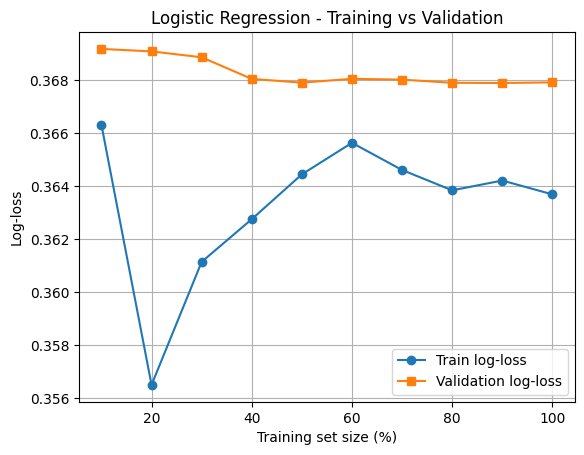

In [ ]:
# block 2 - Logistic Regression: Training vs Validation log-loss curve
import numpy as np
from sklearn.metrics import log_loss

train_sizes = np.linspace(0.1, 1.0, 10)

train_losses_lr = []
val_losses_lr   = []

for frac in train_sizes:
    n_train = int(frac * X_train.shape[0])

    X_tr_sub = X_train[:n_train]
    y_tr_sub = y_train[:n_train]

    model = LogisticRegression(max_iter=1000, n_jobs=-1)
    model.fit(X_tr_sub, y_tr_sub)

    y_tr_proba  = model.predict_proba(X_tr_sub)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    train_losses_lr.append(log_loss(y_tr_sub, y_tr_proba))
    val_losses_lr.append(log_loss(y_val,    y_val_proba))

plt.figure()
plt.plot(train_sizes * 100, train_losses_lr, marker='o', label='Train log-loss')
plt.plot(train_sizes * 100, val_losses_lr,   marker='s', label='Validation log-loss')
plt.xlabel('Training set size (%)')
plt.ylabel('Log-loss')
plt.title('Logistic Regression - Training vs Validation')
plt.legend()
plt.grid(True)
plt.savefig('logreg_train_val.png')
plt.show()


In [ ]:
# block 3 - Logistic Regression: Test evaluation
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

y_pred_lr  = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression - Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression - Test F1-score:", f1_score(y_test, y_pred_lr))
print("Logistic Regression - Test ROC AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nLogistic Regression - Classification Report:\n",
      classification_report(y_test, y_pred_lr, digits=4))

Logistic Regression - Test Accuracy: 0.8404649011217763
Logistic Regression - Test F1-score: 0.8492432107535107
Logistic Regression - Test ROC AUC: 0.9155768879721174

Logistic Regression - Classification Report:
               precision    recall  f1-score   support

           0     0.8853    0.7822    0.8306      8647
           1     0.8050    0.8987    0.8492      8647

    accuracy                         0.8405     17294
   macro avg     0.8451    0.8405    0.8399     17294
weighted avg     0.8451    0.8405    0.8399     17294



#### Support Vector Machine

In [ ]:
# block 1 - Train SVM model
from sklearn.svm import SVC

svm_clf = SVC(probability=True)  # probability=True to enable predict_proba
svm_clf.fit(X_train, y_train)


SVC(probability=True)

In [ ]:
# block 2 - SVM: Training vs Validation log-loss curve
import numpy as np
from sklearn.metrics import log_loss

train_sizes_svm = np.linspace(0.1, 1.0, 8)  # fewer points; SVM can be slow

train_losses_svm = []
val_losses_svm   = []

for frac in train_sizes_svm:
    n_train = int(frac * X_train.shape[0])

    X_tr_sub = X_train[:n_train]
    y_tr_sub = y_train[:n_train]

    model = SVC(probability=True)
    model.fit(X_tr_sub, y_tr_sub)

    y_tr_proba  = model.predict_proba(X_tr_sub)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    train_losses_svm.append(log_loss(y_tr_sub, y_tr_proba))
    val_losses_svm.append(log_loss(y_val,    y_val_proba))

plt.figure()
plt.plot(train_sizes_svm * 100, train_losses_svm, marker='o', label='Train log-loss')
plt.plot(train_sizes_svm * 100, val_losses_svm,   marker='s', label='Validation log-loss')
plt.xlabel('Training set size (%)')
plt.ylabel('Log-loss')
plt.title('SVM - Training vs Validation')
plt.legend()
plt.grid(True)
plt.savefig('svm_train_val.png')
plt.show()

In [ ]:
# block 3 - SVM: Test evaluation
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

y_pred_svm  = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]

print("SVM - Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM - Test F1-score:", f1_score(y_test, y_pred_svm))
print("SVM - Test ROC AUC:", roc_auc_score(y_test, y_proba_svm))
print("\nSVM - Classification Report:\n",
      classification_report(y_test, y_pred_svm, digits=4))

#### Random Forest

In [ ]:
# block 1 - Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

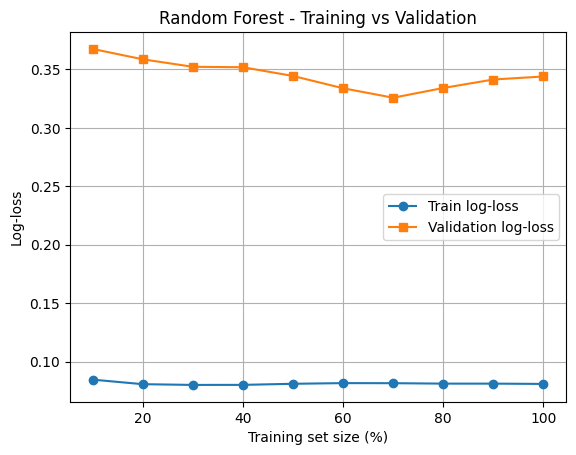

In [ ]:
# block 2 - Random Forest: Training vs Validation log-loss curve
import numpy as np
from sklearn.metrics import log_loss

train_sizes_rf = np.linspace(0.1, 1.0, 10)

train_losses_rf = []
val_losses_rf   = []

for frac in train_sizes_rf:
    n_train = int(frac * X_train.shape[0])

    X_tr_sub = X_train[:n_train]
    y_tr_sub = y_train[:n_train]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr_sub, y_tr_sub)

    y_tr_proba  = model.predict_proba(X_tr_sub)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    train_losses_rf.append(log_loss(y_tr_sub, y_tr_proba))
    val_losses_rf.append(log_loss(y_val,    y_val_proba))

plt.figure()
plt.plot(train_sizes_rf * 100, train_losses_rf, marker='o', label='Train log-loss')
plt.plot(train_sizes_rf * 100, val_losses_rf,   marker='s', label='Validation log-loss')
plt.xlabel('Training set size (%)')
plt.ylabel('Log-loss')
plt.title('Random Forest - Training vs Validation')
plt.legend()
plt.grid(True)
plt.savefig('rf_train_val.png')
plt.show()

In [ ]:
# block 3 - Random Forest: Test evaluation
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

y_pred_rf  = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest - Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest - Test F1-score:", f1_score(y_test, y_pred_rf))
print("Random Forest - Test ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nRandom Forest - Classification Report:\n",
      classification_report(y_test, y_pred_rf, digits=4))


Random Forest - Test Accuracy: 0.8930264831733549
Random Forest - Test F1-score: 0.8961374354367841
Random Forest - Test ROC AUC: 0.9509642552195876

Random Forest - Classification Report:
               precision    recall  f1-score   support

           0     0.9181    0.8631    0.8897      8647
           1     0.8708    0.9230    0.8961      8647

    accuracy                         0.8930     17294
   macro avg     0.8944    0.8930    0.8929     17294
weighted avg     0.8944    0.8930    0.8929     17294



#### XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report

In [ ]:
# Train XGBoost model (with default hyperparameters or tuned if desired)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

eval_set = [(X_train, y_train), (X_val, y_val)]
xgb_model.fit(
    X_train,
    y_train,
    eval_set=eval_set,
    verbose=True  # set True if you want per-iteration logs
)

[0]	validation_0-logloss:0.54396	validation_1-logloss:0.54637
[1]	validation_0-logloss:0.46227	validation_1-logloss:0.46555


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:22:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[2]	validation_0-logloss:0.40947	validation_1-logloss:0.41401
[3]	validation_0-logloss:0.37608	validation_1-logloss:0.38164
[4]	validation_0-logloss:0.35266	validation_1-logloss:0.35920
[5]	validation_0-logloss:0.33544	validation_1-logloss:0.34304
[6]	validation_0-logloss:0.32423	validation_1-logloss:0.33242
[7]	validation_0-logloss:0.31527	validation_1-logloss:0.32376
[8]	validation_0-logloss:0.30911	validation_1-logloss:0.31807
[9]	validation_0-logloss:0.30405	validation_1-logloss:0.31351
[10]	validation_0-logloss:0.29735	validation_1-logloss:0.30733
[11]	validation_0-logloss:0.29315	validation_1-logloss:0.30350
[12]	validation_0-logloss:0.29000	validation_1-logloss:0.30071
[13]	validation_0-logloss:0.28805	validation_1-logloss:0.29905
[14]	validation_0-logloss:0.28421	validation_1-logloss:0.29577
[15]	validation_0-logloss:0.28264	validation_1-logloss:0.29428
[16]	validation_0-logloss:0.27924	validation_1-logloss:0.29178
[17]	validation_0-logloss:0.27715	validation_1-logloss:0.29002


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

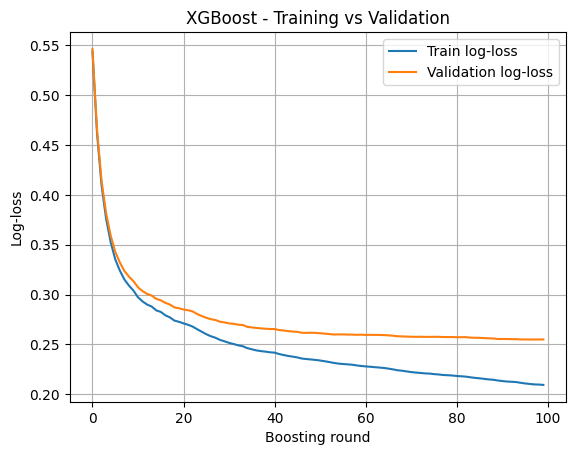

In [ ]:
# Get learning curves from XGBoost
results = xgb_model.evals_result()
train_logloss = results['validation_0']['logloss']
val_logloss   = results['validation_1']['logloss']
epochs = range(len(train_logloss))
plt.figure()
plt.plot(epochs, train_logloss, label='Train log-loss')
plt.plot(epochs, val_logloss,   label='Validation log-loss')
plt.xlabel('Boosting round')
plt.ylabel('Log-loss')
plt.title('XGBoost - Training vs Validation')
plt.legend()
plt.grid(True)
plt.savefig('xgb_train_val.png') # Save the plot as a PNG file
plt.show()

In [ ]:
# Evaluate on test set
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]  # probability of class 1 (conversion)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1-score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

Test Accuracy: 0.8995027177055627
Test F1-score: 0.9025456992261972
Test ROC AUC: 0.9578529379104026

Classification Report:
               precision    recall  f1-score   support

           0     0.9261    0.8683    0.8963      8647
           1     0.8760    0.9307    0.9025      8647

    accuracy                         0.8995     17294
   macro avg     0.9011    0.8995    0.8994     17294
weighted avg     0.9011    0.8995    0.8994     17294



#### Permutation feature importance

In [ ]:
from sklearn.inspection import permutation_importance
# Compute permutation importance on the validation set (or test set)
perm_result = permutation_importance(xgb_model, X_val, y_val, n_repeats=5, scoring='f1', random_state=0)
importances = perm_result.importances_mean  # average importance score for each feature
# Get feature importances in the original feature order (1-grams, 2-grams, motifs)
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")

P(1): 0.1828
P(2): 0.0990
P(3): 0.0008
P(4): 0.0014
P(6): 0.0000
P(1,1): 0.0217
P(1,2): 0.1030
P(1,3): 0.0002
P(1,4): 0.0003
P(1,6): 0.0000
P(2,1): 0.0844
P(2,2): 0.0122
P(2,3): 0.0011
P(2,4): 0.0012
P(2,6): 0.0000
P(3,1): 0.0011
P(3,2): 0.0011
P(3,3): 0.0000
P(3,4): 0.0003
P(3,6): 0.0000
P(4,1): 0.0041
P(4,2): -0.0000
P(4,3): 0.0000
P(4,4): 0.0009
P(4,6): 0.0000
P(6,1): 0.0000
P(6,2): 0.0000
P(6,3): 0.0000
P(6,4): 0.0000
P(6,6): 0.0000
Z1: 0.0113
Z2: 0.0566
Z3: 0.0256
Z4: 0.0106
Z5: 0.0010
Z6: 0.0002
h_z: 0.0590
hour_sin: -0.0006
hour_cos: -0.0006
dow_sin: -0.0002
dow_cos: 0.0000


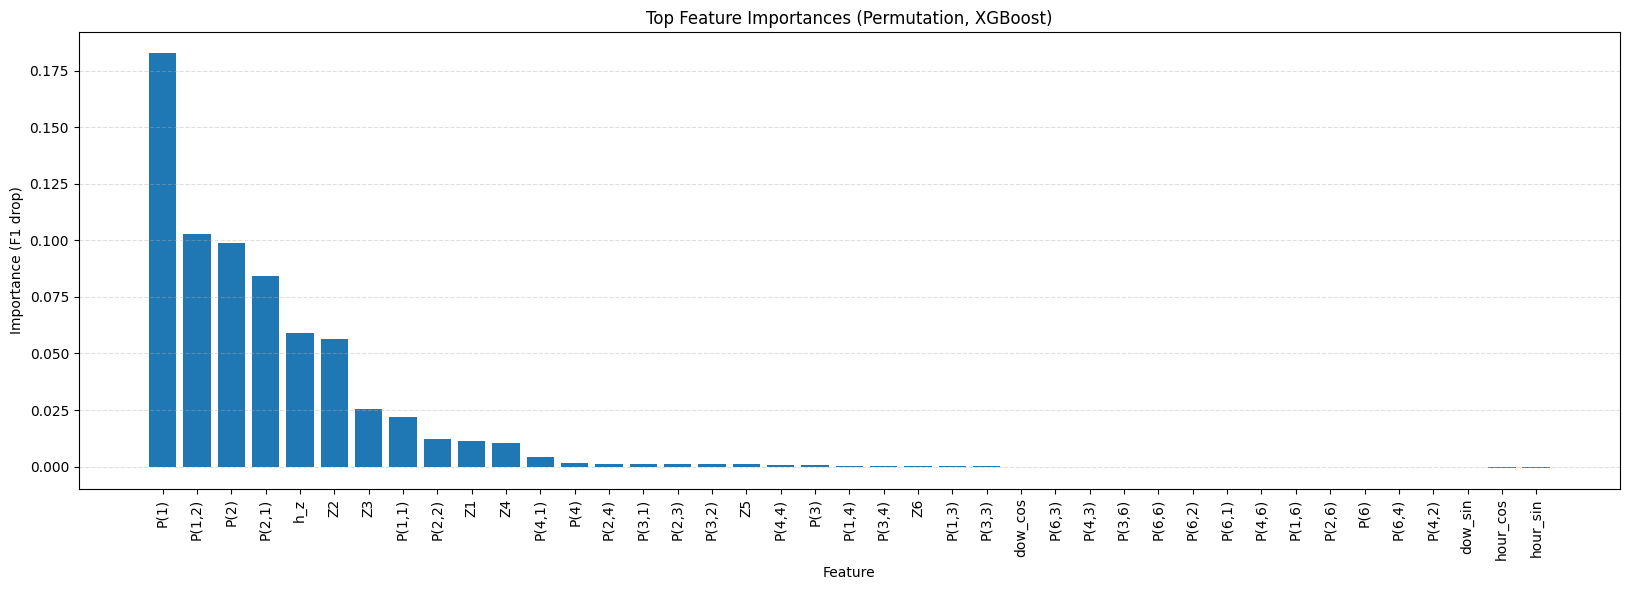

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- config ----
TOP_K = 41  # number of features to show

importances = np.array(importances)

# Indices of top-k features sorted by *descending* importance
sorted_idx = np.argsort(importances)[::-1]     # all features, high → low
top_idx = sorted_idx[:TOP_K]                  # take top K

top_importances = importances[top_idx]
top_names = [feature_names[i] for i in top_idx]

# x positions for bars
x = np.arange(len(top_importances))

plt.figure(figsize=(max(10, 0.4 * len(top_names)), 6))

plt.bar(x, top_importances)
plt.xticks(x, top_names, rotation=90)
plt.ylabel('Importance (F1 drop)')
plt.xlabel('Feature')
plt.title('Top Feature Importances (Permutation, XGBoost)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fi_vertical.png', dpi=300)
plt.show()


#### XGBoost gain importance

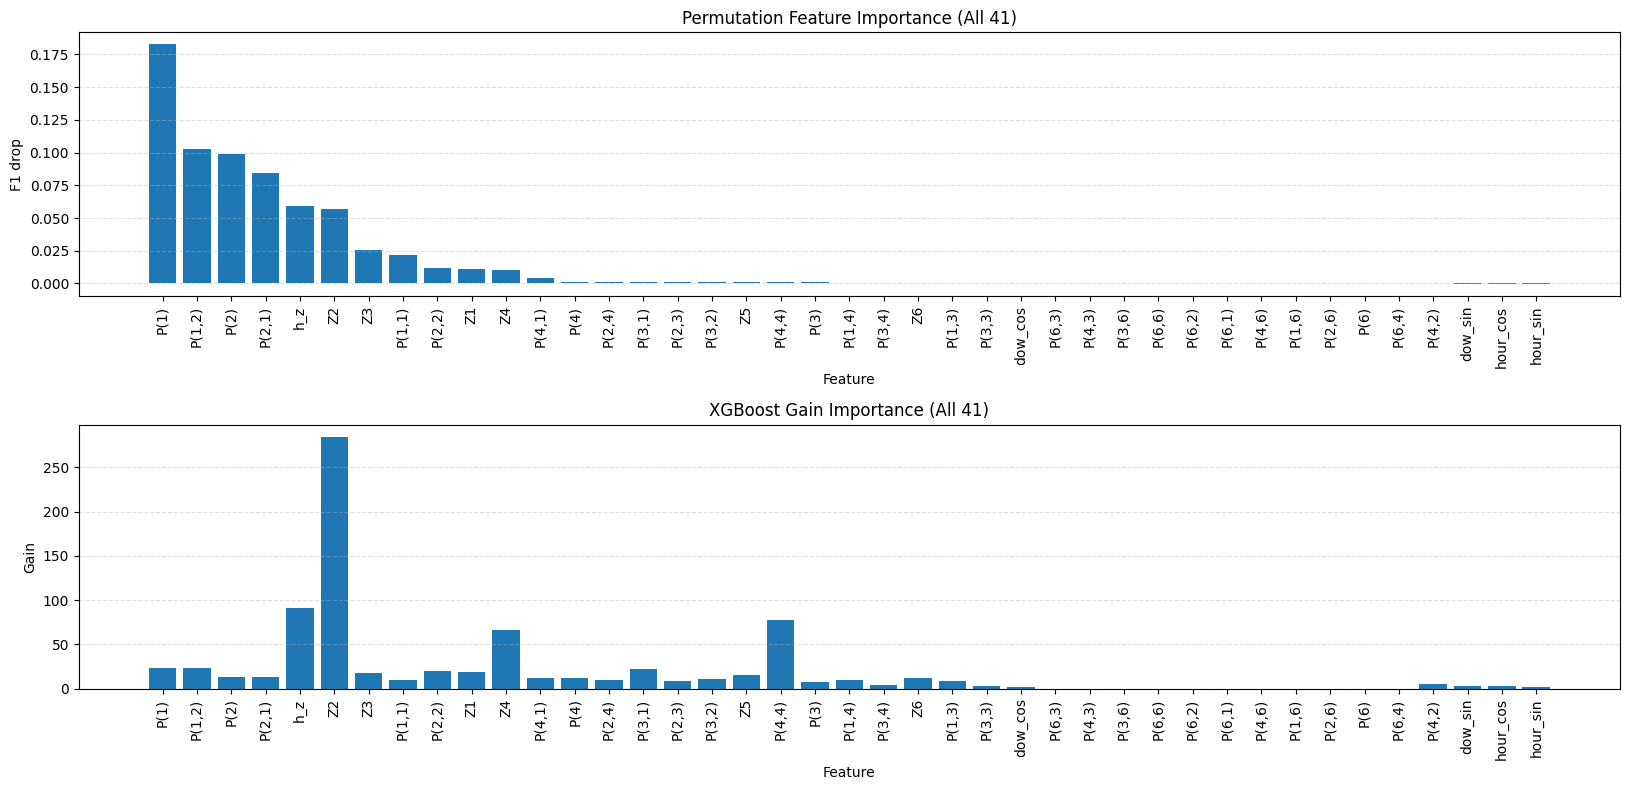

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb  # make sure xgboost is installed

# ---- config ----
TOP_K = 41  # number of features to show

# importances: permutation importance values (1D array-like)
# feature_names: list of feature names (same length as importances)
# xgb_model: trained XGBoost model (XGBClassifier / XGBRegressor)

importances = np.array(importances)

# ---- Permutation importance: get top-K, sorted descending ----
sorted_idx = np.argsort(importances)[::-1]   # all features: high → low
top_idx = sorted_idx[:TOP_K]

top_importances = importances[top_idx]
top_names = [feature_names[i] for i in top_idx]

# ---- XGBoost gain importance ----
booster = xgb_model.get_booster()
gain_dict = booster.get_score(importance_type='gain')  # dict: feature -> gain

# Handle both 'f0', 'f1', ... and real column-name keys
if gain_dict and all(k.startswith('f') and k[1:].isdigit() for k in gain_dict.keys()):
    # keys are like 'f0', 'f1', ...
    gain_full = np.array([gain_dict.get(f"f{i}", 0.0) for i in range(len(feature_names))])
else:
    # keys are actual feature names
    gain_full = np.array([gain_dict.get(name, 0.0) for name in feature_names])

top_gain = gain_full[top_idx]

# ---- Plot: stacked subplots, same feature order ----
x = np.arange(len(top_importances))

fig, axes = plt.subplots(
    2, 1,
    figsize=(max(12, 0.4 * len(top_names)), 8),  # wider for many labels
    sharex=False  # <- important: don't share x so both can have labels
)

# ---- 1) Permutation Feature Importance ----
axes[0].bar(x, top_importances)
axes[0].set_ylabel('F1 drop')
axes[0].set_xlabel('Feature')
axes[0].set_title('Permutation Feature Importance (All {})'.format(TOP_K))
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_names, rotation=90)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# ---- 2) XGBoost Gain Importance ----
axes[1].bar(x, top_gain)
axes[1].set_ylabel('Gain')
axes[1].set_xlabel('Feature')
axes[1].set_title('XGBoost Gain Importance (All {})'.format(TOP_K))
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_names, rotation=90)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fi_perm_vs_gain_option2.png', dpi=300)
plt.show()


In [ ]:
# import matplotlib.pyplot as plt

# # Plot feature importances in the grouped order (1g, 2g, HVG)
# plt.figure(figsize=(12,5))
# plt.bar(range(len(importances)), importances, color='skyblue')
# plt.xticks(range(len(importances)), feature_names, rotation=90)
# plt.xlabel('Feature')
# plt.ylabel('Importance (F1 drop)')
# plt.title('Permutation Feature Importance (XGBoost)')
# plt.tight_layout()
# plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization (optional)
shap.initjs()

# Create a SHAP TreeExplainer using your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Create the summary plot but don't show it yet
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=20,
    plot_type="dot",
    show=False          # 👈 important: prevents immediate display
)

# Save current figure as PNG
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()            # optional: close the figure


In [ ]:
import pickle

# Save model to a pickle file
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

### Deep Learning

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Prepare sequence data for PyTorch (use the same train/val/test split indices derived earlier)
train_sequences = [sequences[i] for i in train_idx]
train_labels = [labels[i] for i in train_idx]
val_sequences = [sequences[i] for i in val_idx]
val_labels = [labels[i] for i in val_idx]
test_sequences = [sequences[i] for i in test_idx]
test_labels = [labels[i] for i in test_idx]

# Define an LSTM classifier model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, pooling='last'):
        super(LSTMClassifier, self).__init__()
        self.pooling = pooling
        # Embedding layer to encode symbols (vocab: 0 for PAD, 1-6 for actual symbols)
        self.embed = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        # x: tensor of shape (batch, seq_len) with padded sequences
        # lengths: tensor of actual lengths for each sequence in the batch
        embedded = self.embed(x)  # (batch, seq_len, embed_dim)
        # Pack the sequence for LSTM to ignore pads
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)
        if self.pooling == 'last':
            # h_n contains the final hidden state for each sequence (shape: [1, batch, hidden_size] for 1-layer LSTM)
            last_hidden = h_n[-1]   # (batch, hidden_size)
            out = self.fc(last_hidden)  # (batch, 1)
        elif self.pooling == 'avg':
            # Pad back to get LSTM outputs for each time step
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
            # Compute average of outputs for each sequence (excluding pads)
            # Sum along time dimension and divide by length (lengths are broadcastable after unsqueeze)
            sum_out = torch.sum(lstm_out, dim=1)  # (batch, hidden_size)
            avg_out = sum_out / lengths.unsqueeze(1)  # divide each vector by its sequence length
            out = self.fc(avg_out)  # (batch, 1)
        else:
            raise ValueError("Pooling must be 'last' or 'avg'")
        return out  # raw logits

# Dataset class for sequences
class SequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Collate function to pad sequences in a batch
def collate_fn(batch):
    # batch is a list of (sequence, label) tuples
    batch_seqs = [torch.tensor(seq, dtype=torch.long) for seq, lbl in batch]
    batch_labels = torch.tensor([lbl for seq, lbl in batch], dtype=torch.float32)
    # Pad sequences to the same length
    lengths = torch.tensor([len(seq) for seq in batch_seqs], dtype=torch.long)
    padded_seqs = nn.utils.rnn.pad_sequence(batch_seqs, batch_first=True, padding_value=0)
    # Note: We use 0 as PAD index (not used in actual symbol set 1-6)
    return padded_seqs, lengths, batch_labels

# Create DataLoaders for train, val, test
train_dataset = SequenceDataset(train_sequences, train_labels)
val_dataset   = SequenceDataset(val_sequences, val_labels)
test_dataset  = SequenceDataset(test_sequences, test_labels)
batch_size = 128  # as per best hyperparams&#8203;:contentReference[oaicite:43]{index=43}
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          collate_fn=collate_fn, pin_memory=True)

# Initialize the LSTM model
vocab_size = 1 + 6  # 0 (PAD) + symbols 1-6
hidden_size = 32    # using best found for S2L-last&#8203;:contentReference[oaicite:44]{index=44}
embed_dim = 16      # embedding dimension (can be equal to hidden or smaller; 16 is chosen here)
model = LSTMClassifier(vocab_size=vocab_size, embed_dim=embed_dim, hidden_size=hidden_size, pooling='last')
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # best LR for last pooling&#8203;:contentReference[oaicite:45]{index=45}

# Training loop with early stopping
epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    for X_batch, lengths, y_batch in train_loader:
        # Move to GPU/CPU
        X_batch = X_batch.to(device)
        lengths = lengths.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch, lengths)
        loss = criterion(logits.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, lengths, y_batch in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, lengths)
            loss = criterion(logits.squeeze(), y_batch)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # save best model parameters
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

# Load best model weights
model.load_state_dict(best_model_state)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: train_loss=0.2940, val_loss=0.2499
Epoch 2: train_loss=0.2469, val_loss=0.2472
Epoch 3: train_loss=0.2425, val_loss=0.2375
Epoch 4: train_loss=0.2386, val_loss=0.2420
Epoch 5: train_loss=0.2357, val_loss=0.2318
Epoch 6: train_loss=0.2342, val_loss=0.2295
Epoch 7: train_loss=0.2318, val_loss=0.2329
Epoch 8: train_loss=0.2307, val_loss=0.2388
Epoch 9: train_loss=0.2294, val_loss=0.2281
Epoch 10: train_loss=0.2277, val_loss=0.2248
Epoch 11: train_loss=0.2265, val_loss=0.2254
Epoch 12: train_loss=0.2243, val_loss=0.2230
Epoch 13: train_loss=0.2238, val_loss=0.2227
Epoch 14: train_loss=0.2227, val_loss=0.2258
Epoch 15: train_loss=0.2236, val_loss=0.2222
Epoch 16: train_loss=0.2213, val_loss=0.2210
Epoch 17: train_loss=0.2220, val_loss=0.2208
Epoch 18: train_loss=0.2196, val_loss=0.2200
Epoch 19: train_loss=0.2182, val_loss=0.2182
Epoch 20: train_loss=0.2193, val_loss=0.2181
Epoch 21: train_loss=0.2183, val_loss=0.2196
Epoch 22: train_loss=0.2182, val_loss=0.2200
Epoch 23: train_los

<All keys matched successfully>

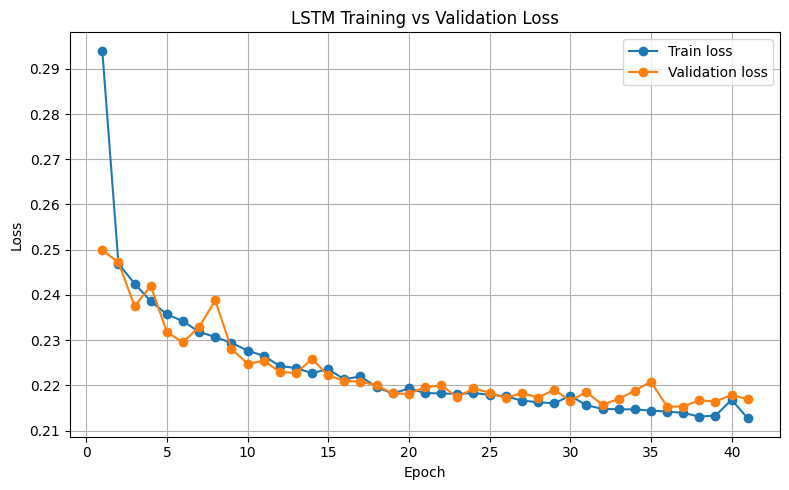

In [ ]:
import re
import matplotlib.pyplot as plt

log_text = """
Epoch 1: train_loss=0.2940, val_loss=0.2499
Epoch 2: train_loss=0.2469, val_loss=0.2472
Epoch 3: train_loss=0.2425, val_loss=0.2375
Epoch 4: train_loss=0.2386, val_loss=0.2420
Epoch 5: train_loss=0.2357, val_loss=0.2318
Epoch 6: train_loss=0.2342, val_loss=0.2295
Epoch 7: train_loss=0.2318, val_loss=0.2329
Epoch 8: train_loss=0.2307, val_loss=0.2388
Epoch 9: train_loss=0.2294, val_loss=0.2281
Epoch 10: train_loss=0.2277, val_loss=0.2248
Epoch 11: train_loss=0.2265, val_loss=0.2254
Epoch 12: train_loss=0.2243, val_loss=0.2230
Epoch 13: train_loss=0.2238, val_loss=0.2227
Epoch 14: train_loss=0.2227, val_loss=0.2258
Epoch 15: train_loss=0.2236, val_loss=0.2222
Epoch 16: train_loss=0.2213, val_loss=0.2210
Epoch 17: train_loss=0.2220, val_loss=0.2208
Epoch 18: train_loss=0.2196, val_loss=0.2200
Epoch 19: train_loss=0.2182, val_loss=0.2182
Epoch 20: train_loss=0.2193, val_loss=0.2181
Epoch 21: train_loss=0.2183, val_loss=0.2196
Epoch 22: train_loss=0.2182, val_loss=0.2200
Epoch 23: train_loss=0.2181, val_loss=0.2174
Epoch 24: train_loss=0.2183, val_loss=0.2193
Epoch 25: train_loss=0.2179, val_loss=0.2184
Epoch 26: train_loss=0.2176, val_loss=0.2172
Epoch 27: train_loss=0.2166, val_loss=0.2183
Epoch 28: train_loss=0.2163, val_loss=0.2173
Epoch 29: train_loss=0.2160, val_loss=0.2190
Epoch 30: train_loss=0.2177, val_loss=0.2166
Epoch 31: train_loss=0.2156, val_loss=0.2185
Epoch 32: train_loss=0.2148, val_loss=0.2157
Epoch 33: train_loss=0.2147, val_loss=0.2170
Epoch 34: train_loss=0.2147, val_loss=0.2188
Epoch 35: train_loss=0.2144, val_loss=0.2208
Epoch 36: train_loss=0.2142, val_loss=0.2153
Epoch 37: train_loss=0.2139, val_loss=0.2153
Epoch 38: train_loss=0.2131, val_loss=0.2167
Epoch 39: train_loss=0.2133, val_loss=0.2164
Epoch 40: train_loss=0.2168, val_loss=0.2179
Epoch 41: train_loss=0.2127, val_loss=0.2169
Early stopping triggered.
<All keys matched successfully>
"""

# Parse the logs
train_losses = []
val_losses = []

pattern = re.compile(r"train_loss=([0-9.]+), val_loss=([0-9.]+)")
for line in log_text.splitlines():
    m = pattern.search(line)
    if m:
        train_losses.append(float(m.group(1)))
        val_losses.append(float(m.group(2)))

# Plot
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train loss')
plt.plot(epochs, val_losses, marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lstm_train_val_loss_from_log.png', dpi=300)
plt.show()

In [ ]:
model.eval()
y_pred = []
y_scores = []
with torch.no_grad():
    for X_batch, lengths, y_batch in test_loader:
        X_batch = X_batch.to(device)
        lengths = lengths.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch, lengths)
        prob = torch.sigmoid(logits).squeeze()  # convert logits to probability
        # Predicted label (0 or 1) using 0.5 threshold
        pred = (prob >= 0.5).long()
        y_pred.extend(pred.tolist())
        y_scores.extend(prob.tolist())

y_test_true = np.array(test_labels)
y_test_pred = np.array(y_pred)
y_test_proba = np.array(y_scores)
print("LSTM Test F1-score:", f1_score(y_test_true, y_test_pred))
print("LSTM Test ROC AUC:", roc_auc_score(y_test_true, y_test_proba))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred, digits=4))

LSTM Test F1-score: 0.9113909689130928
LSTM Test ROC AUC: 0.970458753385304

Classification Report:
               precision    recall  f1-score   support

           0     0.9261    0.8904    0.9079      8647
           1     0.8944    0.9290    0.9114      8647

    accuracy                         0.9097     17294
   macro avg     0.9103    0.9097    0.9096     17294
weighted avg     0.9103    0.9097    0.9096     17294



In [ ]:
import pickle

with open("lstm_full_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
# import pickle

# with open("lstm_full_model.pkl", "rb") as f:
#     model = pickle.load(f)

In [ ]:
torch.save(model.state_dict(), "lstm_model_state.pt")

In [ ]:
# model = LSTMClassifier(vocab_size, embed_dim, hidden_size, pooling='last')
# model.load_state_dict(torch.load("lstm_model_state.pt", map_location=device))
# model.to(device)
# model.eval()


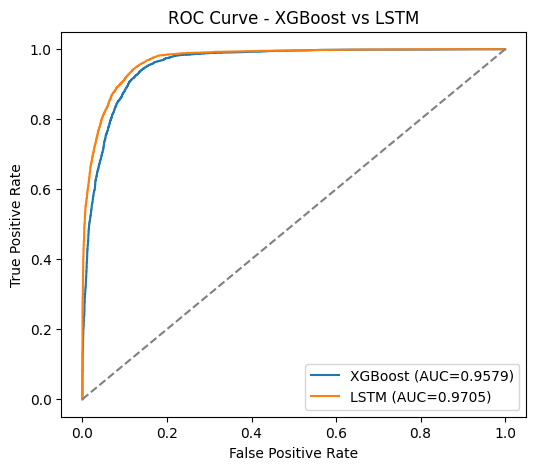

In [ ]:
from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba)   # XGBoost
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_true, y_test_proba)  # LSTM

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba):.4f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={roc_auc_score(y_test_true, y_test_proba):.4f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost vs LSTM")
plt.legend()
plt.savefig('roc_curve_2.png') # Save the plot as a PNG file
plt.show()

### Early prediction

- on sequences of length 5, 10, and 15

In [ ]:
def slice_sequences(sequences, labels, max_len):
    sliced_seqs = []
    new_labels = []
    for seq, lab in zip(sequences, labels):
        new_seq = seq[:max_len]            # take first max_len interactions
        if len(new_seq) == 0:
            continue
        sliced_seqs.append(new_seq)
        new_labels.append(lab)
    return sliced_seqs, new_labels


In [ ]:
def make_loader(seqs, labs):
    ds = SequenceDataset(seqs, labs)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        pin_memory=True
    )


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

def evaluate_loader(loader, true_labels):
    model.eval()
    y_pred = []
    y_scores = []
    with torch.no_grad():
        for X_batch, lengths, y_batch in loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, lengths)
            prob = torch.sigmoid(logits).squeeze()
            pred = (prob >= 0.5).long()

            y_pred.extend(pred.tolist())
            y_scores.extend(prob.tolist())

    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    true_labels = np.array(true_labels)

    print("F1-score:", f1_score(true_labels, y_pred))
    print("ROC AUC :", roc_auc_score(true_labels, y_scores))
    print("\nClassification Report:\n", classification_report(true_labels, y_pred, digits=4))


In [ ]:
for L in [5, 10, 15, 20, 30]:
    print("="*50)
    print(f"Evaluating using first {L} interactions")
    print("="*50)

    seqs_L, labs_L = slice_sequences(test_sequences, test_labels, L)
    loader_L = make_loader(seqs_L, labs_L)   # same make_loader as before
    evaluate_loader(loader_L, labs_L)        # same evaluate_loader as before

Evaluating using first 5 interactions


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-score: 0.013547646383467279
ROC AUC : 0.6271509705103511

Classification Report:
               precision    recall  f1-score   support

           0     0.5016    0.9995    0.6680      8647
           1     0.9365    0.0068    0.0135      8647

    accuracy                         0.5032     17294
   macro avg     0.7191    0.5032    0.3408     17294
weighted avg     0.7191    0.5032    0.3408     17294

Evaluating using first 10 interactions


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-score: 0.17288884214954253
ROC AUC : 0.7602422162965129

Classification Report:
               precision    recall  f1-score   support

           0     0.5238    0.9954    0.6864      8647
           1     0.9536    0.0951    0.1729      8647

    accuracy                         0.5452     17294
   macro avg     0.7387    0.5452    0.4296     17294
weighted avg     0.7387    0.5452    0.4296     17294

Evaluating using first 15 interactions


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-score: 0.5274006216260428
ROC AUC : 0.9052975213830344

Classification Report:
               precision    recall  f1-score   support

           0     0.6046    0.9589    0.7416      8647
           1     0.9008    0.3728    0.5274      8647

    accuracy                         0.6659     17294
   macro avg     0.7527    0.6659    0.6345     17294
weighted avg     0.7527    0.6659    0.6345     17294

Evaluating using first 20 interactions


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-score: 0.8723705979673836
ROC AUC : 0.9426644833132227

Classification Report:
               precision    recall  f1-score   support

           0     0.8597    0.8965    0.8777      8647
           1     0.8919    0.8537    0.8724      8647

    accuracy                         0.8751     17294
   macro avg     0.8758    0.8751    0.8750     17294
weighted avg     0.8758    0.8751    0.8750     17294

Evaluating using first 30 interactions


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-score: 0.9068733614499032
ROC AUC : 0.9632604570600729

Classification Report:
               precision    recall  f1-score   support

           0     0.9177    0.8909    0.9041      8647
           1     0.8940    0.9201    0.9069      8647

    accuracy                         0.9055     17294
   macro avg     0.9059    0.9055    0.9055     17294
weighted avg     0.9059    0.9055    0.9055     17294

